## Feature influence on views count
This notebook section estimates which input features most influence post `views` (or `views_count` if present) using a Random Forest regressor + permutation importance.

In [1]:
import pandas as pd
import numpy as np

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestRegressor
from sklearn.inspection import permutation_importance
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

# Load data
file_path = "../data/raw/raw.csv"
df = pd.read_csv(file_path)

# Use views_count if present, otherwise fallback to views
target_col = "views_count" if "views_count" in df.columns else "views"

# Basic feature engineering
if "post_datetime" in df.columns:
    df["post_datetime"] = pd.to_datetime(df["post_datetime"], errors="coerce")
    df["post_month"] = df["post_datetime"].dt.month
    df["post_dayofweek"] = df["post_datetime"].dt.dayofweek
    df["post_hour"] = df["post_datetime"].dt.hour

if "hashtags" in df.columns:
    df["hashtag_count"] = (
        df["hashtags"].fillna("").str.split().apply(lambda x: len([h for h in x if h.startswith("#")]))
    )

# Drop high-cardinality/free-text/id columns from modeling
drop_cols = ["post_id", "post_datetime", "hashtags", target_col]
feature_cols = [col for col in df.columns if col not in drop_cols]

X = df[feature_cols].copy()
y = df[target_col].copy()

# Handle missing values
for col in X.select_dtypes(include=["number"]).columns:
    X[col] = X[col].fillna(X[col].median())
for col in X.select_dtypes(exclude=["number"]).columns:
    X[col] = X[col].fillna("Unknown")

categorical_cols = X.select_dtypes(exclude=["number"]).columns.tolist()
numeric_cols = X.select_dtypes(include=["number"]).columns.tolist()

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols),
        ("num", "passthrough", numeric_cols),
    ]
)

model = RandomForestRegressor(
    n_estimators=300,
    random_state=42,
    n_jobs=-1,
)

pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", model),
    ]
)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

pipeline.fit(X_train, y_train)
y_pred = pipeline.predict(X_test)

print(f"Target column used: {target_col}")
print(f"R² on test set: {r2_score(y_test, y_pred):.4f}")
print(f"MAE on test set: {mean_absolute_error(y_test, y_pred):,.2f}")

Target column used: views
R² on test set: 0.9899
MAE on test set: 228,244.08


In [5]:
import pandas as pd
import numpy as np
import statsmodels.formula.api as smf

# Load data
df = pd.read_csv("../data/raw/raw.csv")

# Define hypothesis target and main predictor
target_col = "views_count" if "views_count" in df.columns else "views"
positive_col = "likes" if "likes" in df.columns else None

if positive_col is None:
    raise ValueError("No clear positive reaction column found (expected: 'likes').")

# Optional controls (only use those that exist)
control_candidates = [
    "comments", "shares", "engagement_rate",
    "platform", "content_type", "topic", "language", "region",
    "sentiment_score", "is_viral",
    "post_hour", "post_dayofweek", "post_month",
    "follower_count", "followers"
]

# Time features if available
if "post_datetime" in df.columns:
    dt = pd.to_datetime(df["post_datetime"], errors="coerce")
    df["post_hour"] = dt.dt.hour
    df["post_dayofweek"] = dt.dt.dayofweek
    df["post_month"] = dt.dt.month

controls = [c for c in control_candidates if c in df.columns and c not in [target_col, positive_col]]

# Build model dataframe
model_df = df[[target_col, positive_col] + controls].copy()
model_df = model_df.replace([np.inf, -np.inf], np.nan).dropna()

# Log transform to reduce heavy skew in counts
model_df["log_views"] = np.log1p(model_df[target_col].astype(float))
model_df["log_likes"] = np.log1p(model_df[positive_col].astype(float))

# Formula with categorical handling
terms = ["log_likes"] + [f"C({c})" if model_df[c].dtype == "object" else c for c in controls]
formula = "log_views ~ " + " + ".join(terms)

# Robust OLS
ols = smf.ols(formula=formula, data=model_df).fit(cov_type="HC3")

beta = ols.params["log_likes"]
p_two = ols.pvalues["log_likes"]

# One-sided p-value for H1: positive reactions improve popularity (beta > 0)
p_one = (p_two / 2) if beta > 0 else (1 - p_two / 2)
alpha = 0.05

print("Hypothesis test: Do positive audience reactions improve popularity?")
print(f"Popularity target: {target_col}")
print(f"Positive reaction proxy: {positive_col}")
print(f"beta(log_likes -> log_views): {beta:.6f}")
print(f"p-value (one-sided, H1: beta > 0): {p_one:.6g}")
print("Decision:", "Reject H0 (supports improvement effect)" if p_one < alpha else "Fail to reject H0")
print(f"R-squared: {ols.rsquared:.4f}")

# Compact output for key coefficient
display(ols.summary2().tables[1].loc[["log_likes"]])

Hypothesis test: Do positive audience reactions improve popularity?
Popularity target: views
Positive reaction proxy: likes
beta(log_likes -> log_views): 0.667394
p-value (one-sided, H1: beta > 0): 1.86352e-309
Decision: Reject H0 (supports improvement effect)
R-squared: 0.8691


/Users/dinukadilshan/Documents/workspace/TPSM/.venv/lib/python3.12/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 28, but rank is 27
  warnings.warn('covariance of constraints does not have full '


,Coef.,Std.Err.,z,P>|z|,[0.025,0.975]
log_likes,0.667394,0.017757,37.585371,3.727040e-309,0.632592,0.702197


=== Dataset shape ===
Rows: 2,000
Columns: 15

=== Target/class distribution ===
          count  percent
is_viral                
0           602     30.1
1          1398     69.9

=== Views distribution (quantiles) ===
count    2.000000e+03
mean     4.284860e+06
std      3.246193e+06
min      4.380000e+03
1%       8.129208e+04
5%       3.648625e+05
25%      1.652742e+06
50%      3.469408e+06
75%      6.348078e+06
95%      1.081928e+07
99%      1.295647e+07
max      1.437179e+07
Name: views, dtype: float64

=== Numeric feature summary ===


,mean,std,min,25%,50%,75%,max
views,4.284860e+06,3.246193e+06,4380.0000,1.652742e+06,3.469408e+06,6.348078e+06,1.437179e+07
likes,2.453292e+05,1.450324e+05,292.0000,1.189038e+05,2.398310e+05,3.723235e+05,4.999830e+05
comments,2.478693e+04,1.443329e+04,14.0000,1.233775e+04,2.451950e+04,3.711625e+04,4.998900e+04
shares,4.993698e+04,2.901282e+04,127.0000,2.569875e+04,5.021200e+04,7.543300e+04,9.997700e+04
engagement_rate,1.578519e-01,5.354574e-01,0.0357,5.797500e-02,8.450000e-02,1.425250e-01,1.257320e+01
sentiment_score,-5.665000e-04,5.749115e-01,-1.0000,-5.070000e-01,1.000000e-03,4.952500e-01,9.990000e-01
is_viral,6.990000e-01,4.588074e-01,0.0000,0.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00



=== Top categorical distributions (top 5 each) ===

=== Distribution diagnostics for views ===
Skewness (views): 0.8344
Skewness (log1p(views)): -1.4165
Jarque-Bera p-value (views): 3.334e-51
Jarque-Bera p-value (log1p(views)): 0.000e+00
Interpretation:
- Raw views are not normal (strong right-skew).
- log1p(views) is closer to normal, but still not perfectly normal with this sample size.
- t and F are distributions of test statistics, not the dataset itself.


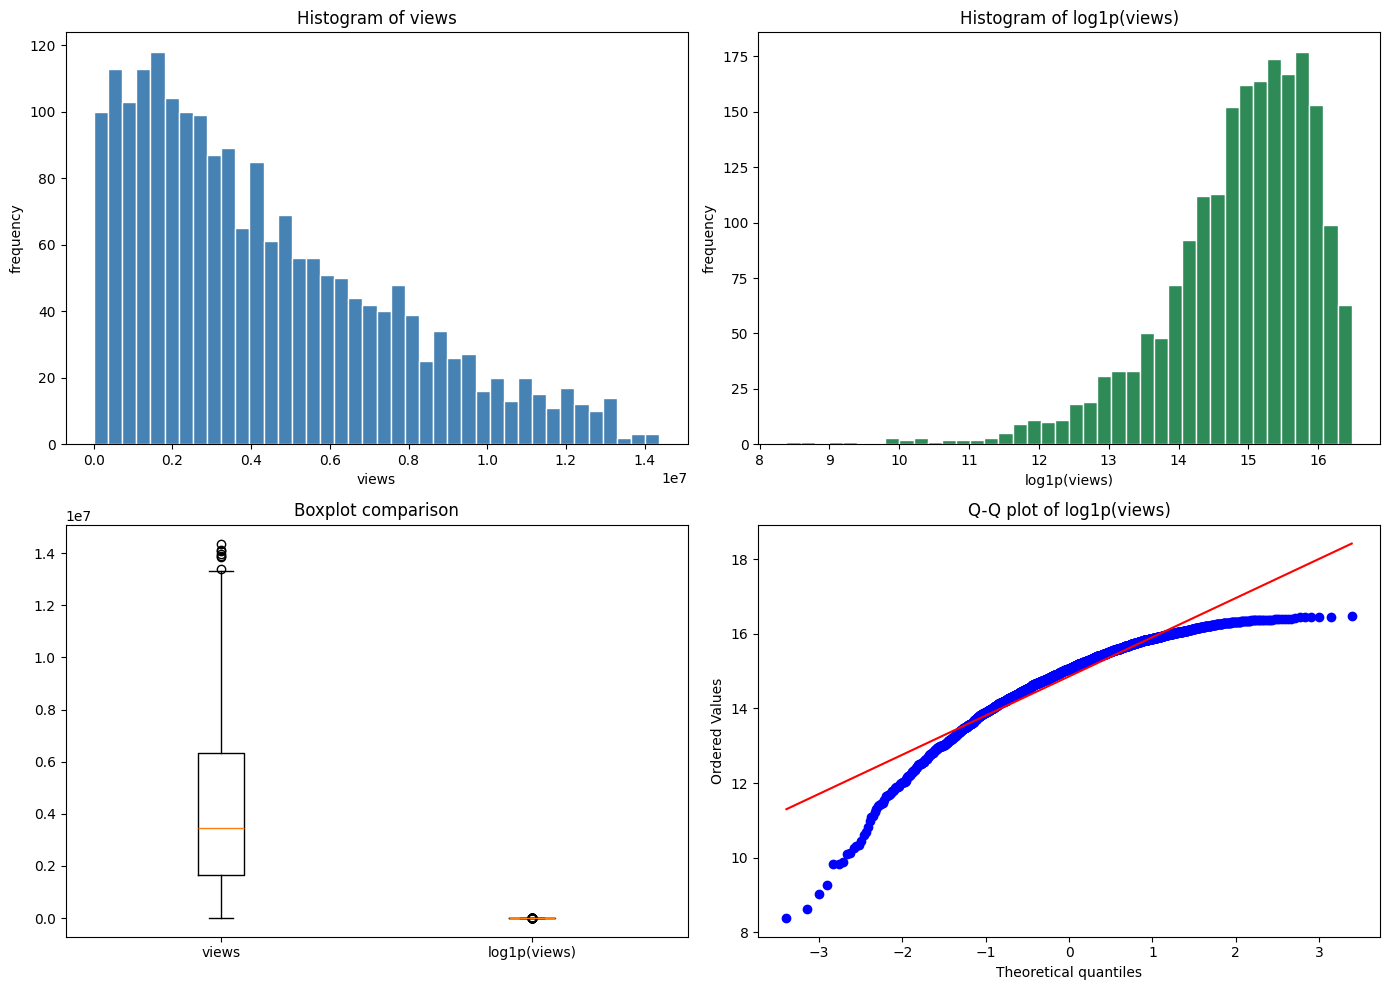

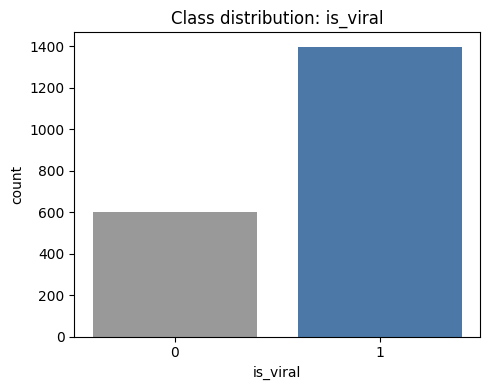

In [9]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt

# Load dataset
df_dist = pd.read_csv("../data/raw/raw.csv")

print("=== Dataset shape ===")
print(f"Rows: {df_dist.shape[0]:,}")
print(f"Columns: {df_dist.shape[1]}")

print("\n=== Target/class distribution ===")
if "is_viral" in df_dist.columns:
    viral_counts = df_dist["is_viral"].value_counts(dropna=False).sort_index()
    viral_pct = (df_dist["is_viral"].value_counts(normalize=True, dropna=False).sort_index() * 100).round(2)
    print(pd.DataFrame({"count": viral_counts, "percent": viral_pct}))

if "views" in df_dist.columns:
    print("\n=== Views distribution (quantiles) ===")
    print(df_dist["views"].describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]))

print("\n=== Numeric feature summary ===")
numeric_cols = df_dist.select_dtypes(include=[np.number]).columns.tolist()
display(df_dist[numeric_cols].describe().T[["mean", "std", "min", "25%", "50%", "75%", "max"]])

print("\n=== Top categorical distributions (top 5 each) ===")
cat_cols = [c for c in df_dist.columns if df_dist[c].dtype == "object"]
for c in cat_cols:
    print(f"\n{c}")
    vc = df_dist[c].value_counts(dropna=False).head(5)
    vp = (df_dist[c].value_counts(normalize=True, dropna=False).head(5) * 100).round(2)
    print(pd.DataFrame({"count": vc, "percent": vp}))

print("\n=== Distribution diagnostics for views ===")
x = df_dist["views"].astype(float).dropna()
x_log = np.log1p(x)

print(f"Skewness (views): {stats.skew(x):.4f}")
print(f"Skewness (log1p(views)): {stats.skew(x_log):.4f}")

jb_views = stats.jarque_bera(x)
jb_log = stats.jarque_bera(x_log)
print(f"Jarque-Bera p-value (views): {jb_views.pvalue:.3e}")
print(f"Jarque-Bera p-value (log1p(views)): {jb_log.pvalue:.3e}")

print("Interpretation:")
print("- Raw views are not normal (strong right-skew).")
print("- log1p(views) is closer to normal, but still not perfectly normal with this sample size.")
print("- t and F are distributions of test statistics, not the dataset itself.")

# ---------- Visualizations ----------
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Histogram: raw views
axes[0, 0].hist(x, bins=40, color="steelblue", edgecolor="white")
axes[0, 0].set_title("Histogram of views")
axes[0, 0].set_xlabel("views")
axes[0, 0].set_ylabel("frequency")

# Histogram: log views
axes[0, 1].hist(x_log, bins=40, color="seagreen", edgecolor="white")
axes[0, 1].set_title("Histogram of log1p(views)")
axes[0, 1].set_xlabel("log1p(views)")
axes[0, 1].set_ylabel("frequency")

# Boxplot comparison
axes[1, 0].boxplot([x, x_log], tick_labels=["views", "log1p(views)"], vert=True)
axes[1, 0].set_title("Boxplot comparison")

# Q-Q plot for log1p(views)
stats.probplot(x_log, dist="norm", plot=axes[1, 1])
axes[1, 1].set_title("Q-Q plot of log1p(views)")

plt.tight_layout()
plt.show()

# Optional: class balance bar chart
if "is_viral" in df_dist.columns:
    plt.figure(figsize=(5, 4))
    counts = df_dist["is_viral"].value_counts().sort_index()
    plt.bar(counts.index.astype(str), counts.values, color=["#999999", "#4C78A8"])
    plt.title("Class distribution: is_viral")
    plt.xlabel("is_viral")
    plt.ylabel("count")
    plt.tight_layout()
    plt.show()